In [1]:
import pandas as pd
import glob

files = glob.glob("*.csv")

print(files)

['Friday-02-03-2018_TrafficForML_CICFlowMeter.csv', 'Friday-16-02-2018_TrafficForML_CICFlowMeter.csv', 'Friday-23-02-2018_TrafficForML_CICFlowMeter.csv', 'Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv', 'Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv', 'Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv', 'Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv', 'Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv', 'Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv', 'Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv']


In [2]:
# merge all csv files

df_list = []

for file in files:
    data = pd.read_csv(file, nrows=50000)
    df_list.append(data)

df = pd.concat(df_list, ignore_index=True)

print("Dataset Shape:", df.shape)

df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9000\2363175581.py:6: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: 

Dataset Shape: (500000, 84)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773,202,0,...,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0,38,0,...,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527,385,0,...,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
3,443,6,02/03/2018 08:47:40,132,2,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141,517,0,...,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN


In [3]:
# remove missing values

df = df.dropna()

# remove duplicates
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (50000, 84)


In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# convert labels into numbers
df['Label'] = encoder.fit_transform(df['Label'])

print(df['Label'].value_counts())

Label
1    49927
0       73
Name: count, dtype: int64


In [5]:
# features and target

X = df.drop('Label', axis=1)

y = df['Label']

print(X.shape)
print(y.shape)

(50000, 83)
(50000,)


In [6]:
from sklearn.model_selection import train_test_split

# split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 83)
(10000, 83)


In [7]:
from sklearn.ensemble import RandomForestClassifier

# create model
model = RandomForestClassifier(n_estimators=50)

# train model
model.fit(X_train, y_train)

print("Model Training Completed")

ValueError: could not convert string to float: '20/02/2018 10:22:28'

In [8]:
# keep only numeric columns

X = df.select_dtypes(include=['int64', 'float64'])

# remove target column from features
X = X.drop('Label', axis=1)

y = df['Label']

print(X.shape)
print(y.shape)

(50000, 1)
(50000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 1)
(10000, 1)


In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [11]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


Matplotlib is building the font cache; this may take a moment.


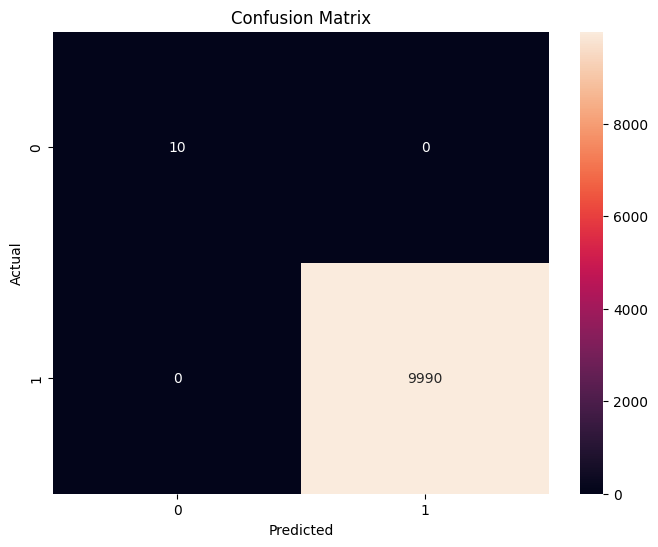

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

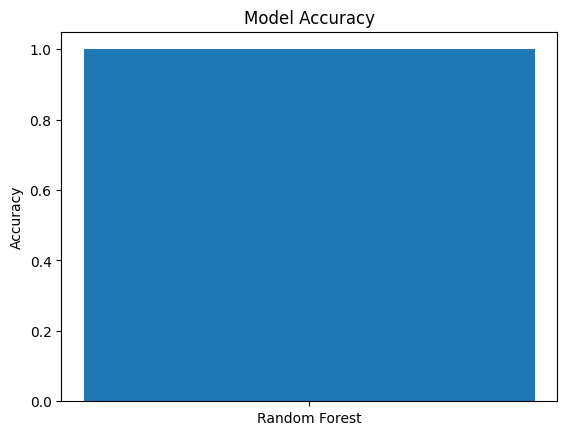

In [13]:
plt.bar(["Random Forest"], [accuracy])

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

[[  10    0]
 [   0 9990]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00      9990

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

